## Assignment 6: Perceptron

Part one: Step function

In [724]:
import pandas as pd  #for file reading into table
import matplotlib.pyplot as plt
import numpy as np

#To load data - upload file to session storage /content/data.csv

df = pd.read_csv("data.csv", header=None) #no headers included in data file
#print(df.head())  #check how data is organized to debug data read issue

In [725]:
#print(df.columns)  #shows column names to help detect the empty headers

In [726]:
#prepare data to fit model input from assignment pseudcode
X = df[[0,1]].values  #features from first two columns
y = df[2].values      #labels

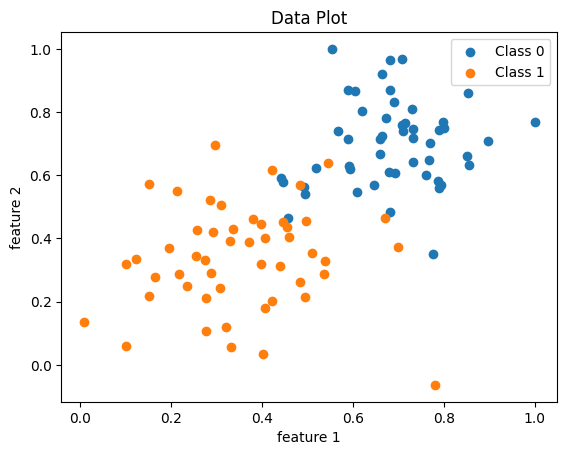

In [727]:
class0 = []
class1 = []

#loop through data and separate data into the two groups
for i in range(len(X)):
    if y[i] == 0:
        class0.append(X[i])
    else:
        class1.append(X[i])

#convert lists to useable numpy arrays to plot
class0 = np.array(class0)
class1 = np.array(class1)

#plot the data
plt.scatter(class0[:, 0], class0[:, 1], label="Class 0")
plt.scatter(class1[:, 0], class1[:, 1], label="Class 1")

plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.title("Data Plot")

plt.show()

In [728]:
def preceptron_step(x, w, b):
  wx_product = 0

  #calculate weight and feature products in linear combination
  for i in range(len(w)):
    wx_product += w[i] * x[i]

  #add bias
  predict = wx_product + b

  #classify prediction using a step function
  if predict >= 0: #check sign of prediction
    return 1
  else:
    return 0

In [729]:
np.random.seed(7)#generate same numbers each iteration, seed 7 is cleaner visual
w = np.random.randn(2)#generate random starting wieghts
b = np.random.randn()#generate random starting bais

#list of line traces to show dashed green
line_trace = [(w.copy(), b)]

#############################
#  Experimental parameters
#############################
r = 0.01            #learning rate
epochs = 100         #number of iterations

for epoch in range(epochs):

    for i in range(len(X)):
        y_hat = preceptron_step(X[i], w, b)
        error = y[i] - y_hat   #calculate error

        if error != 0:
          b = b + r * error            #update bias, b+r(y-y_hat) --> b
          w = w + r * error * X[i]     #update weights, w_i+r(y-y_hat)x_i --> w_i



    line_trace.append((w.copy(), b))  #push updated line to history

r = 0.01
epochs = 100


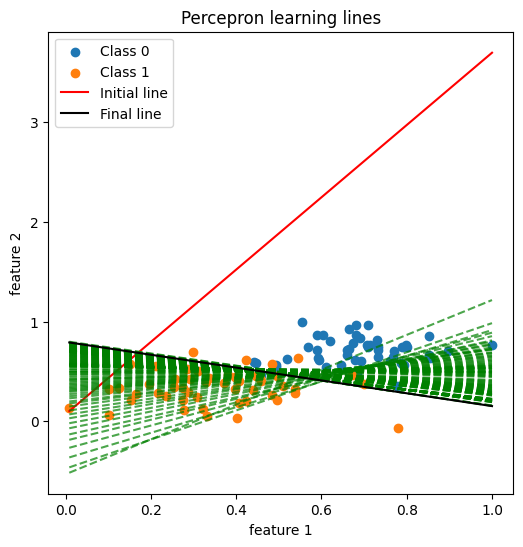

In [730]:
class0 = []
class1 = []

#loop through data and separate data into the two groups
for i in range(len(X)):
    if y[i] == 0:
        class0.append(X[i])
    else:
        class1.append(X[i])

#convert lists to useable numpy arrays to plot
class0 = np.array(class0)
class1 = np.array(class1)

plt.figure(figsize=(6, 6))
plt.scatter(class0[:, 0], class0[:, 1], label="Class 0")
plt.scatter(class1[:, 0], class1[:, 1], label="Class 1")

#use minimum and maximum values in data set to x-axis range
x_vals = np.array([X[:, 0].min(), X[:, 0].max()])


for i, (w_line, b_line) in enumerate(line_trace):
    y_vals = -(w_line[0] * x_vals + b_line) / w_line[1] #solve for y

    #plot lines for visual
    if i == 0:
        plt.plot(x_vals, y_vals, color="red", label="Initial line")
    elif i == len(line_trace) - 1:
        plt.plot(x_vals, y_vals, color="black", label="Final line")
    else:
        plt.plot(x_vals, y_vals, color="green", linestyle="--", alpha=0.7)

print("r =",r)
print("epochs =", epochs)

plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.title("Percepron learning lines")

plt.show()

Part 2: Sigmoid

r = 0.01
epochs = 100


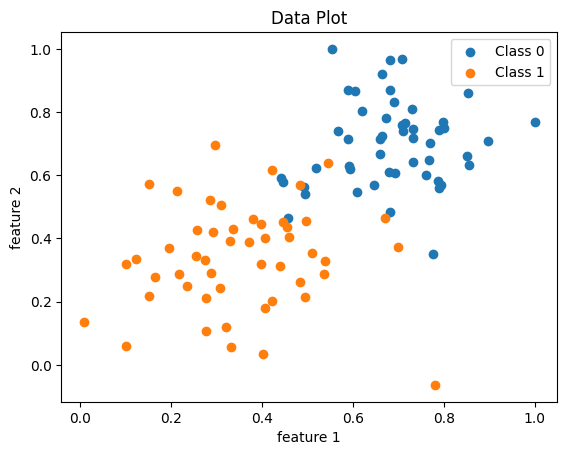

In [731]:
class0 = []
class1 = []

#loop through data and separate into the two groups
for i in range(len(X)):
    if y[i] == 0:
        class0.append(X[i])
    else:
        class1.append(X[i])

#convert lists to useable numpy arrays to plot
class0 = np.array(class0)
class1 = np.array(class1)

#plot the data
plt.scatter(class0[:, 0], class0[:, 1], label="Class 0")
plt.scatter(class1[:, 0], class1[:, 1], label="Class 1")

print("r =",r)
print("epochs =", epochs)

plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.title("Data Plot")

plt.show()

In [732]:
def preceptron_sig(x, w, b):
  wx_product = 0

  #calculate weight and feature products in linear combination
  for i in range(len(w)):
    wx_product += w[i] * x[i]

  #add bias
  predict_grdt = wx_product + b

  #classify prediction using a sigmoid function
  return 1 / (1 + np.exp(-predict_grdt))

In [733]:
np.random.seed(7)#generate same numbers each iteration, seed 7 is cleaner visual
w = np.random.randn(2)#generate random starting wieghts
b = np.random.randn()#generate random starting bais

#############################
#  Experimental parameters
#############################
r = 0.9           #learning rate
epochs = 300      #number of iterations

#list copied weights and the bias to show dashed green
line_trace2 = [(w.copy(), b)]

#lists that store error history
epoch_history = []
loss_history = []


for epoch in range(epochs):
    for i in range(len(X)):
        y_hat = preceptron_sig(X[i], w, b)
        error = y[i] - y_hat

        b = b + r * error#update bias, b+r(y-y_hat) --> b
        w = w + r * error * X[i]#update weights, w_i+r(y-y_hat)x_i --> w_i

    if(epoch +1) % 10 == 0:
        #calculate log loss
        total_loss = 0

        for j in range(len(X)):
            y_hat = preceptron_sig(X[j], w, b)

            #solve log(0) issue using clip function from numpy
            y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)

            total_loss += -(y[j] * np.log(y_hat) + (1 - y[j]) * np.log(1-y_hat))

        average_loss = total_loss / len(X)

        #push to error history
        epoch_history.append(epoch + 1)
        loss_history.append(average_loss)

    line_trace2.append((w.copy(), b))#push updated line to history

r = 0.9
epochs = 300


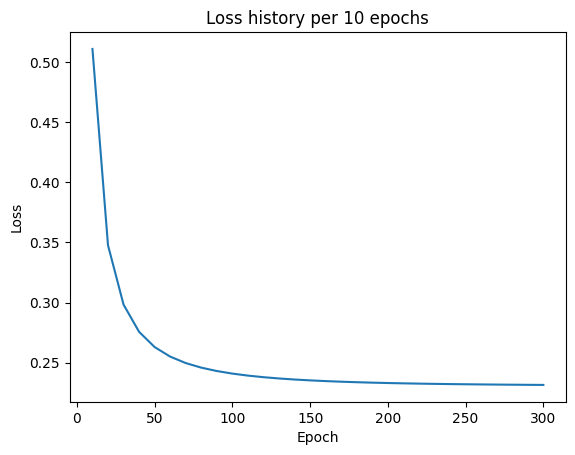

In [734]:
#Visualization for Loss history

print("r =",r)
print("epochs =", epochs)

plt.plot(epoch_history, loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss history per 10 epochs")

plt.show()

r = 0.9
epochs = 300


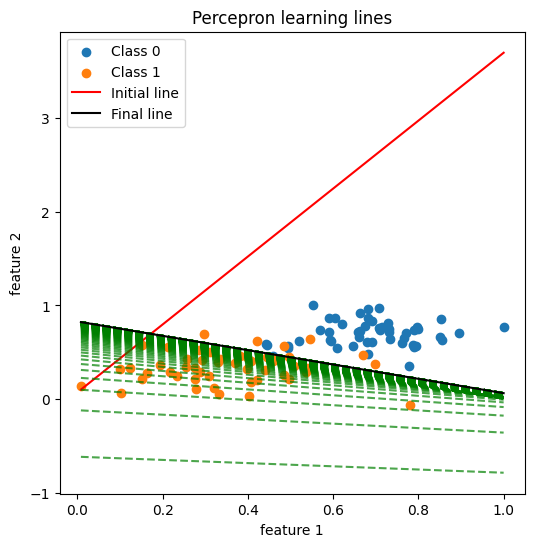

In [735]:
class0 = []
class1 = []

#loop through data and separate data into the two groups
for i in range(len(X)):
    if y[i] == 0:
        class0.append(X[i])
    else:
        class1.append(X[i])

#convert lists to useable numpy arrays to plot
class0 = np.array(class0)
class1 = np.array(class1)

plt.figure(figsize=(6, 6))
plt.scatter(class0[:, 0], class0[:, 1], label="Class 0")
plt.scatter(class1[:, 0], class1[:, 1], label="Class 1")

#use minimum and maximum values in data set to x-axis range
x_vals = np.array([X[:, 0].min(), X[:, 0].max()])


for i, (w_line, b_line) in enumerate(line_trace2):
    y_vals = -(w_line[0] * x_vals + b_line) / w_line[1] #solve for y

    #plot lines for visual
    if i == 0:
        plt.plot(x_vals, y_vals, color="red", label="Initial line")
    elif i == len(line_trace2) - 1:
        plt.plot(x_vals, y_vals, color="black", label="Final line")
    else:
        plt.plot(x_vals, y_vals, color="green", linestyle="--", alpha=0.7)


print("r =",r)
print("epochs =", epochs)

plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.title("Percepron learning lines")

plt.show()